In [1]:
import CNN_model_helper as CNN_model_helper
import numpy as np, pandas as pd, optuna, torch
from sklearn.model_selection import StratifiedKFold
from CNN_model import CNNRegressor
from pathlib import Path
import json, torch
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
from CNN_model_helper import (evaluate_fold, plot_training_progress, find_optimal_clusters)

import sys
from pathlib import Path

/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_prefix_MW = '../MW/artifacts_threshold/'

df = pd.read_parquet(data_prefix_MW + "scaled_final_dataset_RDKit_60(split)_MW(label)_70(threshold).parquet")
df.head()

,SMILES,MP,Type,MW_label,RDKit_fr_NH1,RDKit_VSA_EState7,RDKit_EState_VSA8,RDKit_VSA_EState9,RDKit_SlogP_VSA4,RDKit_fr_pyridine,...,RDKit_RingCount,RDKit_FpDensityMorgan2,RDKit_SPS,RDKit_fr_ester,RDKit_VSA_EState1,RDKit_SMR_VSA6,RDKit_fr_bicyclic,RDKit_SMR_VSA5,RDKit_NumAtomStereoCenters,RDKit_PEOE_VSA9
0,O=Cc1ccccc1OC(=O)C,38.0,Train,0,-0.463609,-0.191767,-0.680559,-0.154896,-0.65812,-0.266204,...,-0.673751,0.832282,-0.604616,1.449116,-0.194700,-0.677532,-0.462140,-0.440317,-0.364053,-0.327314
1,CCOC(=O)Nc1ccc2c(c1)nn(n2)C1CCCC1,121.5,Train,0,1.305228,0.542864,0.131266,-0.154896,-0.65812,-0.266204,...,0.857023,0.870914,0.051270,-0.333509,-0.190130,0.636993,0.335393,0.689560,-0.364053,0.483141
2,O1CC1COc1cccc(c1)OCC1OC1,34.0,Train,0,-0.463609,-0.209136,-0.680559,-0.154896,-0.65812,-0.266204,...,0.857023,-0.519820,1.110011,-0.333509,0.671746,2.235970,-0.462140,-0.252123,0.687644,0.547773
3,CCCCCCCCCCCCCCCC(=O)O.N,22.0,Train,0,-0.463609,3.115121,-0.318254,-0.154896,-0.65812,-0.266204,...,-1.439138,-1.678766,-0.497288,-0.333509,-0.445016,-0.677532,-0.462140,2.761131,-0.364053,-0.963694
4,CC(=O)Oc1ccc(c(c1)C)OC(=O)C,41.0,Train,0,-0.463609,-0.321321,-0.680559,-0.154896,0.04661,-0.266204,...,-0.673751,-0.133505,-0.559669,3.231740,0.069747,-0.677532,-0.462140,0.052855,-0.364053,-0.963694


In [3]:
df_train = df[
    (df["Type"] == "Train") &
    (df["MW_label"] == 0)
].copy()

print("Shape:", df_train.shape)
print(df_train[["Type", "MW_label"]].value_counts())

Shape: (7234, 76)
Type   MW_label
Train  0           7234
Name: count, dtype: int64


In [4]:
df_train.head()

,SMILES,MP,Type,MW_label,RDKit_fr_NH1,RDKit_VSA_EState7,RDKit_EState_VSA8,RDKit_VSA_EState9,RDKit_SlogP_VSA4,RDKit_fr_pyridine,...,RDKit_RingCount,RDKit_FpDensityMorgan2,RDKit_SPS,RDKit_fr_ester,RDKit_VSA_EState1,RDKit_SMR_VSA6,RDKit_fr_bicyclic,RDKit_SMR_VSA5,RDKit_NumAtomStereoCenters,RDKit_PEOE_VSA9
0,O=Cc1ccccc1OC(=O)C,38.0,Train,0,-0.463609,-0.191767,-0.680559,-0.154896,-0.65812,-0.266204,...,-0.673751,0.832282,-0.604616,1.449116,-0.194700,-0.677532,-0.462140,-0.440317,-0.364053,-0.327314
1,CCOC(=O)Nc1ccc2c(c1)nn(n2)C1CCCC1,121.5,Train,0,1.305228,0.542864,0.131266,-0.154896,-0.65812,-0.266204,...,0.857023,0.870914,0.051270,-0.333509,-0.190130,0.636993,0.335393,0.689560,-0.364053,0.483141
2,O1CC1COc1cccc(c1)OCC1OC1,34.0,Train,0,-0.463609,-0.209136,-0.680559,-0.154896,-0.65812,-0.266204,...,0.857023,-0.519820,1.110011,-0.333509,0.671746,2.235970,-0.462140,-0.252123,0.687644,0.547773
3,CCCCCCCCCCCCCCCC(=O)O.N,22.0,Train,0,-0.463609,3.115121,-0.318254,-0.154896,-0.65812,-0.266204,...,-1.439138,-1.678766,-0.497288,-0.333509,-0.445016,-0.677532,-0.462140,2.761131,-0.364053,-0.963694
4,CC(=O)Oc1ccc(c(c1)C)OC(=O)C,41.0,Train,0,-0.463609,-0.321321,-0.680559,-0.154896,0.04661,-0.266204,...,-0.673751,-0.133505,-0.559669,3.231740,0.069747,-0.677532,-0.462140,0.052855,-0.364053,-0.963694


X_scaled shape: (7234, 72)
Num features: 72


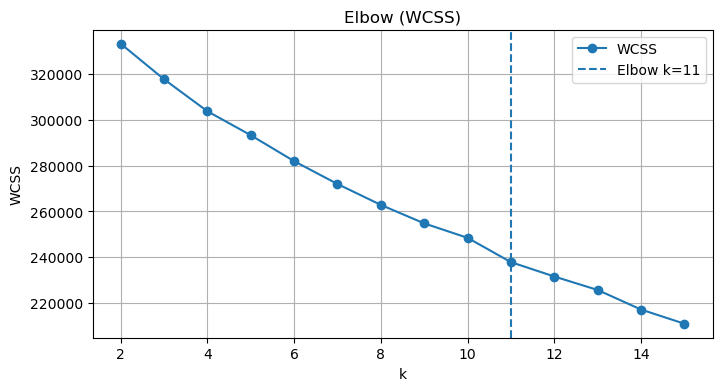

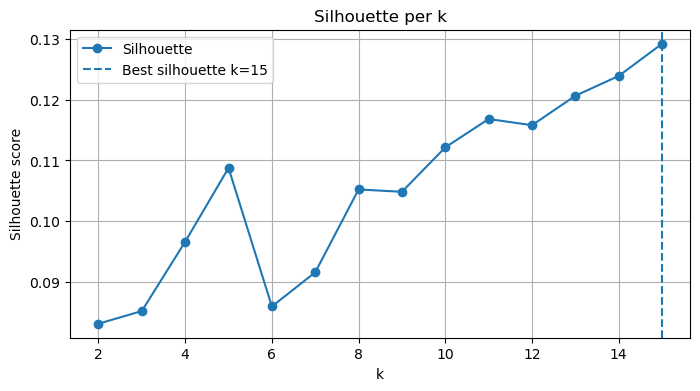

Elbow k: 11 | Best silhouette k: 15 | Selected k_opt: 11


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator


# 2) Define feature columns (already scaled), Exclude metadata/labels/non-features

exclude = {"SMILES", "MP", "Type", "MW_label"}
num_cols = df_train.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

X_scaled = df_train[feature_cols].to_numpy(dtype=np.float32)

print("X_scaled shape:", X_scaled.shape)
print("Num features:", len(feature_cols))


# 3) Find optimal k

random_state = 0
k_opt = find_optimal_clusters(X_scaled=X_scaled, max_k=15, random_state=random_state, plot=True)

if k_opt is None:
    k_opt = 3
    print("No clear elbow/silhouette; defaulting to k=3.")


# 4) Fit final kmeans + assign clusters

final_kmeans = KMeans(
    n_clusters=int(k_opt),
    init="k-means++",
    n_init=10,
    random_state=random_state
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

assert len(cluster_labels) == len(df_train), "Cluster labels length != df rows (mismatch)."

df_clustered = df_train.copy()
df_clustered["Structure_Cluster"] = cluster_labels


In [6]:
df_clustered.head()

,SMILES,MP,Type,MW_label,RDKit_fr_NH1,RDKit_VSA_EState7,RDKit_EState_VSA8,RDKit_VSA_EState9,RDKit_SlogP_VSA4,RDKit_fr_pyridine,...,RDKit_FpDensityMorgan2,RDKit_SPS,RDKit_fr_ester,RDKit_VSA_EState1,RDKit_SMR_VSA6,RDKit_fr_bicyclic,RDKit_SMR_VSA5,RDKit_NumAtomStereoCenters,RDKit_PEOE_VSA9,Structure_Cluster
0,O=Cc1ccccc1OC(=O)C,38.0,Train,0,-0.463609,-0.191767,-0.680559,-0.154896,-0.65812,-0.266204,...,0.832282,-0.604616,1.449116,-0.194700,-0.677532,-0.462140,-0.440317,-0.364053,-0.327314,3
1,CCOC(=O)Nc1ccc2c(c1)nn(n2)C1CCCC1,121.5,Train,0,1.305228,0.542864,0.131266,-0.154896,-0.65812,-0.266204,...,0.870914,0.051270,-0.333509,-0.190130,0.636993,0.335393,0.689560,-0.364053,0.483141,8
2,O1CC1COc1cccc(c1)OCC1OC1,34.0,Train,0,-0.463609,-0.209136,-0.680559,-0.154896,-0.65812,-0.266204,...,-0.519820,1.110011,-0.333509,0.671746,2.235970,-0.462140,-0.252123,0.687644,0.547773,4
3,CCCCCCCCCCCCCCCC(=O)O.N,22.0,Train,0,-0.463609,3.115121,-0.318254,-0.154896,-0.65812,-0.266204,...,-1.678766,-0.497288,-0.333509,-0.445016,-0.677532,-0.462140,2.761131,-0.364053,-0.963694,9
4,CC(=O)Oc1ccc(c(c1)C)OC(=O)C,41.0,Train,0,-0.463609,-0.321321,-0.680559,-0.154896,0.04661,-0.266204,...,-0.133505,-0.559669,3.231740,0.069747,-0.677532,-0.462140,0.052855,-0.364053,-0.963694,3


Fold split & Optimization

In [7]:
TARGET_COL = "MP"

exclude = {"SMILES", TARGET_COL, "Type", "MW_label", "Structure_Cluster"}
num_cols = df_clustered.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

X = df_clustered[feature_cols].to_numpy(np.float32) 
y = df_clustered[TARGET_COL].to_numpy(np.float32)
y_strat = df_clustered["Structure_Cluster"].astype(str).to_numpy()

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=10)
folds = [(tr, va) for tr, va in skf.split(X, y_strat)]

print("Total samples:", len(X))
print("Num features:", X.shape[1])
print("Num folds:", len(folds))
print()

for i, (tr_idx, va_idx) in enumerate(folds):
    print(
        f"Fold {i:2d} | "
        f"Train: {len(tr_idx):4d} | "
        f"Val: {len(va_idx):4d}"
    )


Total samples: 7234
Num features: 72
Num folds: 10

Fold  0 | Train: 6510 | Val:  724
Fold  1 | Train: 6510 | Val:  724
Fold  2 | Train: 6510 | Val:  724
Fold  3 | Train: 6510 | Val:  724
Fold  4 | Train: 6511 | Val:  723
Fold  5 | Train: 6511 | Val:  723
Fold  6 | Train: 6511 | Val:  723
Fold  7 | Train: 6511 | Val:  723
Fold  8 | Train: 6511 | Val:  723
Fold  9 | Train: 6511 | Val:  723


In [8]:
import time
import numpy as np
from pathlib import Path

trial_times = []

def objective(trial):

    dropout_rate  = trial.suggest_float("dropout_rate", 0.2, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    weight_decay  = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    batch_size    = trial.suggest_categorical("batch_size", [16, 32, 64])

    start = time.perf_counter()
    rmses = []

    for fold_idx, (tr_idx, val_idx) in enumerate(folds):

        X_train_scaled = X[tr_idx]
        y_train = y[tr_idx]

        X_val_scaled = X[val_idx]
        y_val = y[val_idx]

        rmse, *_ = evaluate_fold(
            trial=trial,
            fold_idx=fold_idx,
            X_train_scaled=X_train_scaled,
            y_train=y_train,
            X_val_scaled=X_val_scaled,
            y_val=y_val,
            learning_rate=learning_rate,
            batch_size=batch_size,
            hidden_layers=None,   # CNN doesn't use this
            dropout_rate=dropout_rate,
            weight_decay=weight_decay,
            save_checkpoints=False,
            checkpoint_dir=None,
        )

        rmses.append(float(rmse))

    elapsed_min = (time.perf_counter() - start) / 60.0
    trial_times.append(elapsed_min)

    avg_rmse = float(np.mean(rmses))

    trial.set_user_attr("avg_rmse", avg_rmse)
    trial.set_user_attr("fold_rmses", rmses)
    trial.set_user_attr("elapsed_min", elapsed_min)

    print(f"Trial {trial.number} finished in {elapsed_min:.2f} minutes")
    print(f"Trial {trial.number}: Average RMSE = {avg_rmse:.4f}")

    return avg_rmse


def set_optuna_study(n_trials): 
    start_time = time.perf_counter()
    print("Setting up Optuna study...")
    
    # 1) Set up the Optuna study
    study = optuna.create_study(direction='minimize') #minimize return loss
    study.optimize(objective, n_trials=n_trials)  #CHANGE TO 100 AFTER TESTING
    
    # 2) Identify the best hyperparameters
    best_params = study.best_params #best_params holds the dropout, learning rate, and weight decay that gave the lowest best_val_loss
    print("Best hyperparameters:", best_params)
    
    end_time = time.perf_counter()
    elapsed_time = (end_time - start_time) / 60.0
    print(f"Optuna study completed in {elapsed_time:.2f} minutes")
    
    return best_params, study


device = torch.device("cpu")
best_params, study = set_optuna_study(n_trials=20)

[I 2026-03-08 16:09:35,019] A new study created in memory with name: no-name-1577c118-0dd3-423b-98d1-b125872967c6


Setting up Optuna study...
Fold 0: Training CNN on cpu
[Fold 0] Epoch    1 | Train Loss: 123.6493 | Val Loss: 115.9531 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 41.2795 | Val Loss: 40.4849 | ES 1/30
[Fold 0] Epoch  100 | Train Loss: 40.0537 | Val Loss: 40.2520 | ES 20/30
[Fold 0] Early stopping at epoch 110 (best Val Loss: 39.8490)
Fold 1: Training CNN on cpu
[Fold 1] Epoch    1 | Train Loss: 122.9779 | Val Loss: 116.5508 | ES 0/30
[Fold 1] Epoch   50 | Train Loss: 40.8177 | Val Loss: 42.4185 | ES 4/30
[Fold 1] Early stopping at epoch 100 (best Val Loss: 41.6352)
Fold 2: Training CNN on cpu
[Fold 2] Epoch    1 | Train Loss: 123.7339 | Val Loss: 116.4028 | ES 0/30
[Fold 2] Epoch   50 | Train Loss: 40.8574 | Val Loss: 45.9902 | ES 8/30
[Fold 2] Epoch  100 | Train Loss: 37.9780 | Val Loss: 40.6360 | ES 5/30
[Fold 2] Early stopping at epoch 125 (best Val Loss: 39.4045)
Fold 3: Training CNN on cpu
[Fold 3] Epoch    1 | Train Loss: 124.0321 | Val Loss: 117.0092 | ES 0/30
[Fold 3] Epoch   5

[I 2026-03-08 16:57:52,788] Trial 0 finished with value: 40.243656921386716 and parameters: {'dropout_rate': 0.24648095272990994, 'learning_rate': 0.00014488811407329524, 'weight_decay': 1.931591714736726e-05, 'batch_size': 16}. Best is trial 0 with value: 40.243656921386716.


[Fold 9] Early stopping at epoch 152 (best Val Loss: 37.5708)
Trial 0 finished in 48.30 minutes
Trial 0: Average RMSE = 40.2437
Fold 0: Training CNN on cpu
[Fold 0] Epoch    1 | Train Loss: 129.2520 | Val Loss: 129.4832 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 97.2552 | Val Loss: 96.4485 | ES 0/30
[Fold 0] Epoch  100 | Train Loss: 52.8630 | Val Loss: 48.8441 | ES 0/30
[Fold 0] Epoch  150 | Train Loss: 48.9899 | Val Loss: 44.7865 | ES 0/30
[Fold 0] Epoch  200 | Train Loss: 47.5357 | Val Loss: 43.5669 | ES 3/30
[Fold 0] Epoch  250 | Train Loss: 46.0779 | Val Loss: 42.4793 | ES 5/30
[Fold 0] Epoch  300 | Train Loss: 45.2375 | Val Loss: 41.9116 | ES 2/30
[Fold 0] Epoch  350 | Train Loss: 45.0274 | Val Loss: 41.9145 | ES 8/30
[Fold 0] Early stopping at epoch 372 (best Val Loss: 41.7824)
Fold 1: Training CNN on cpu
[Fold 1] Epoch    1 | Train Loss: 129.3442 | Val Loss: 131.1985 | ES 0/30
[Fold 1] Epoch   50 | Train Loss: 94.9560 | Val Loss: 95.3501 | ES 1/30
[Fold 1] Epoch  100 | Train Lo

[I 2026-03-08 18:53:13,107] Trial 1 finished with value: 43.06311149597168 and parameters: {'dropout_rate': 0.36991835690571867, 'learning_rate': 1.0704246074042366e-05, 'weight_decay': 2.485353709050111e-05, 'batch_size': 32}. Best is trial 0 with value: 40.243656921386716.


...

[Fold 9] Early stopping at epoch 94 (best Val Loss: 37.9521)
Trial 17 finished in 43.72 minutes
Trial 17: Average RMSE = 39.7537
Fold 0: Training CNN on cpu
[Fold 0] Epoch    1 | Train Loss: 125.9698 | Val Loss: 121.7594 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 43.2681 | Val Loss: 43.9877 | ES 4/30
[Fold 0] Epoch  100 | Train Loss: 40.8488 | Val Loss: 39.9277 | ES 26/30
[Fold 0] Early stopping at epoch 104 (best Val Loss: 39.8129)
Fold 1: Training CNN on cpu
[Fold 1] Epoch    1 | Train Loss: 126.4301 | Val Loss: 125.5780 | ES 0/30
[Fold 1] Epoch   50 | Train Loss: 42.7369 | Val Loss: 44.0619 | ES 15/30
[Fold 1] Early stopping at epoch 94 (best Val Loss: 41.9545)
Fold 2: Training CNN on cpu
[Fold 2] Epoch    1 | Train Loss: 125.8786 | Val Loss: 121.6763 | ES 0/30
[Fold 2] Epoch   50 | Train Loss: 42.8598 | Val Loss: 41.8633 | ES 15/30
[Fold 2] Epoch  100 | Train Loss: 40.5803 | Val Loss: 40.7909 | ES 13/30
[Fold 2] Epoch  150 | Train Loss: 40.5170 | Val Loss: 40.6240 | ES 18/30
[Fold

[I 2026-03-09 08:22:19,206] Trial 18 finished with value: 40.80099945068359 and parameters: {'dropout_rate': 0.3492259087250272, 'learning_rate': 9.322446398097372e-05, 'weight_decay': 1.2256378354158575e-06, 'batch_size': 16}. Best is trial 9 with value: 39.29232978820801.


[Fold 9] Early stopping at epoch 175 (best Val Loss: 39.1812)
Trial 18 finished in 54.95 minutes
Trial 18: Average RMSE = 40.8010
Fold 0: Training CNN on cpu
[Fold 0] Epoch    1 | Train Loss: 117.0813 | Val Loss: 97.5630 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 42.2896 | Val Loss: 45.2384 | ES 2/30
[Fold 0] Epoch  100 | Train Loss: 40.5237 | Val Loss: 39.1746 | ES 1/30
[Fold 0] Early stopping at epoch 129 (best Val Loss: 38.6416)
Fold 1: Training CNN on cpu
[Fold 1] Epoch    1 | Train Loss: 116.4676 | Val Loss: 97.4784 | ES 0/30
[Fold 1] Epoch   50 | Train Loss: 41.8368 | Val Loss: 44.6460 | ES 2/30
[Fold 1] Epoch  100 | Train Loss: 39.4641 | Val Loss: 41.9810 | ES 8/30
[Fold 1] Early stopping at epoch 122 (best Val Loss: 41.2400)
Fold 2: Training CNN on cpu
[Fold 2] Epoch    1 | Train Loss: 115.1944 | Val Loss: 92.8761 | ES 0/30
[Fold 2] Epoch   50 | Train Loss: 41.5166 | Val Loss: 50.5592 | ES 6/30
[Fold 2] Epoch  100 | Train Loss: 38.2720 | Val Loss: 40.0653 | ES 1/30
[Fold 2] Ea

[I 2026-03-09 09:08:40,624] Trial 19 finished with value: 40.04692268371582 and parameters: {'dropout_rate': 0.38055494903575326, 'learning_rate': 0.0002760354646007438, 'weight_decay': 4.186916460354121e-06, 'batch_size': 16}. Best is trial 9 with value: 39.29232978820801.


[Fold 9] Early stopping at epoch 133 (best Val Loss: 38.2090)
Trial 19 finished in 46.36 minutes
Trial 19: Average RMSE = 40.0469
Best hyperparameters: {'dropout_rate': 0.37366425869750397, 'learning_rate': 0.0006261409781707648, 'weight_decay': 2.187881774854225e-05, 'batch_size': 16}
Optuna study completed in 1019.10 minutes


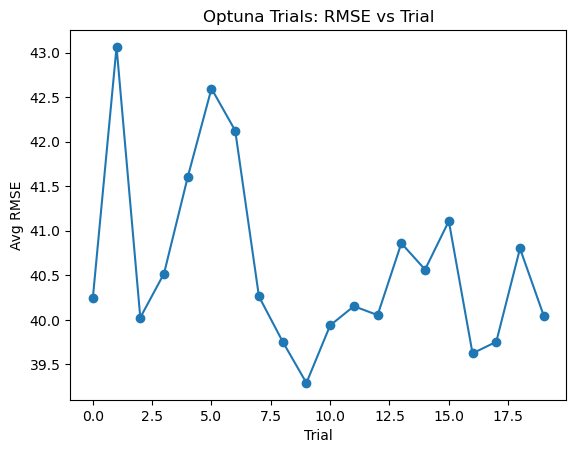

In [9]:
import matplotlib.pyplot as plt

df_trials = study.trials_dataframe(attrs=("number", "value", "user_attrs"))
rmse_by_trial = df_trials["value"].to_numpy()   # value == returned avg_rmse
trial_nums = df_trials["number"].to_numpy()

plt.figure()
plt.plot(trial_nums, rmse_by_trial, marker="o")
plt.xlabel("Trial")
plt.ylabel("Avg RMSE")
plt.title("Optuna Trials: RMSE vs Trial")
plt.show()


In [10]:
# Save the best parameters

print("Best Trial Number:", study.best_trial.number)
print("  RMSE:", study.best_value)
print("  Params:", study.best_params)

Best Trial Number: 9
  RMSE: 39.29232978820801
  Params: {'dropout_rate': 0.37366425869750397, 'learning_rate': 0.0006261409781707648, 'weight_decay': 2.187881774854225e-05, 'batch_size': 16}


In [11]:
# Retrain and Save Models with Best Hyperparameters

BASE = Path.cwd()
artifacts_dir = BASE / "artifacts_CNN"

# ---------- Directories for final best models + checkpoints ----------
best_models_dir = artifacts_dir / "CNN_best_LowMW_RDKit_60(split)_MW(label)_70(threshold)"
best_models_dir.mkdir(parents=True, exist_ok=True)

final_ckpt_dir = BASE / "checkpoints_CNN_best_RDKit_60(split)_MW(label)_70(threshold)"
final_ckpt_dir.mkdir(parents=True, exist_ok=True)

print("Best hyperparameters from Optuna:", best_params)

dropout_rate  = best_params["dropout_rate"]
learning_rate = best_params["learning_rate"]
weight_decay  = best_params["weight_decay"]
batch_size    = best_params["batch_size"]

print("dropout:", dropout_rate, "| lr:", learning_rate, "| wd:", weight_decay, "| batch_size:", batch_size)

final_fold_metrics = []

# ---------- Final training loop for all folds ----------
for fold_idx, (tr_idx, val_idx) in enumerate(folds):
    print(f"\n==================== Final training for fold {fold_idx} ====================")

    X_train_scaled = X[tr_idx]
    y_train        = y[tr_idx]
    X_val_scaled   = X[val_idx]
    y_val          = y[val_idx]

    rmse, r2, q2, model, train_losses, val_losses, stop_epoch = evaluate_fold(
        trial=None,
        fold_idx=fold_idx,
        X_train_scaled=X_train_scaled,
        y_train=y_train,
        X_val_scaled=X_val_scaled,
        y_val=y_val,
        hidden_layers=None,           # placeholder only; CNN does not use this
        learning_rate=learning_rate,
        batch_size=batch_size,
        dropout_rate=dropout_rate,
        weight_decay=weight_decay,
        max_epochs=10**9,
        patience=30,
        min_delta=0.0,
        save_checkpoints=True,
        checkpoint_dir=final_ckpt_dir,
        save_every_n_epochs=15
    )

    # ---------- Save the final (best) model for this fold ----------
    model_path = best_models_dir / f"general_best_fold_{fold_idx}.pt"
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "model_type": "CNNRegressor",
            "dropout_rate": dropout_rate,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "batch_size": batch_size,
            "fold_idx": fold_idx,
            "rmse": rmse,
            "r2": r2,
            "q2": q2,
        },
        model_path,
    )
    print(f"[Fold {fold_idx}] Saved best model to: {model_path}")

    final_fold_metrics.append(
        {
            "Fold": fold_idx,
            "RMSE": rmse,
            "R2": r2,
            "Q2": q2,
            "Stop_Epoch": stop_epoch,
            "Model_Path": str(model_path),
        }
    )

# ---------- Save a summary CSV of all folds ----------
metrics_df = pd.DataFrame(final_fold_metrics)
metrics_path = best_models_dir / "CNN_best_LowMW_RDKit_60(split)_MW(label)_70(threshold).csv"
metrics_df.to_csv(metrics_path, index=False)

print("\n✅ Saved summary of best models across folds to:", metrics_path)
print(metrics_df)

Best hyperparameters from Optuna: {'dropout_rate': 0.37366425869750397, 'learning_rate': 0.0006261409781707648, 'weight_decay': 2.187881774854225e-05, 'batch_size': 16}
dropout: 0.37366425869750397 | lr: 0.0006261409781707648 | wd: 2.187881774854225e-05 | batch_size: 16

==================== Final training for fold 0 ====================
Fold 0: Training CNN on cpu
Checkpoints will be saved to: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW_models/checkpoints_CNN_best_RDKit_60(split)_MW(label)_70(threshold)/fold_0
[Fold 0] Regular checkpoint saved at epoch 1 - RMSE: 52.4101
[Fold 0] Epoch    1 | Train Loss: 95.1581 | Val Loss: 50.9584 | ES 0/30
[Fold 0] Regular checkpoint saved at epoch 15 - RMSE: 43.3433
[Fold 0] Regular checkpoint saved at epoch 30 - RMSE: 43.9446
[Fold 0] Regular checkpoint saved at epoch 45 - RMSE: 40.1950
[Fold 0] Epoch   50 | Train Loss: 41.2097 | Val Loss: 40.3798 | ES 11/30
[Fold 0] Regular checkpoint saved at epoch 60 - RMSE: 40.4487
[Fold 0] Regular ch

TEST SET EVALUATION

In [12]:
data_prefix_MW = '../MW/artifacts_threshold/'

df = pd.read_parquet(data_prefix_MW + "scaled_final_dataset_RDKit_60(split)_MW(label)_70(threshold).parquet")
df.head()

,SMILES,MP,Type,MW_label,RDKit_fr_NH1,RDKit_VSA_EState7,RDKit_EState_VSA8,RDKit_VSA_EState9,RDKit_SlogP_VSA4,RDKit_fr_pyridine,...,RDKit_RingCount,RDKit_FpDensityMorgan2,RDKit_SPS,RDKit_fr_ester,RDKit_VSA_EState1,RDKit_SMR_VSA6,RDKit_fr_bicyclic,RDKit_SMR_VSA5,RDKit_NumAtomStereoCenters,RDKit_PEOE_VSA9
0,O=Cc1ccccc1OC(=O)C,38.0,Train,0,-0.463609,-0.191767,-0.680559,-0.154896,-0.65812,-0.266204,...,-0.673751,0.832282,-0.604616,1.449116,-0.194700,-0.677532,-0.462140,-0.440317,-0.364053,-0.327314
1,CCOC(=O)Nc1ccc2c(c1)nn(n2)C1CCCC1,121.5,Train,0,1.305228,0.542864,0.131266,-0.154896,-0.65812,-0.266204,...,0.857023,0.870914,0.051270,-0.333509,-0.190130,0.636993,0.335393,0.689560,-0.364053,0.483141
2,O1CC1COc1cccc(c1)OCC1OC1,34.0,Train,0,-0.463609,-0.209136,-0.680559,-0.154896,-0.65812,-0.266204,...,0.857023,-0.519820,1.110011,-0.333509,0.671746,2.235970,-0.462140,-0.252123,0.687644,0.547773
3,CCCCCCCCCCCCCCCC(=O)O.N,22.0,Train,0,-0.463609,3.115121,-0.318254,-0.154896,-0.65812,-0.266204,...,-1.439138,-1.678766,-0.497288,-0.333509,-0.445016,-0.677532,-0.462140,2.761131,-0.364053,-0.963694
4,CC(=O)Oc1ccc(c(c1)C)OC(=O)C,41.0,Train,0,-0.463609,-0.321321,-0.680559,-0.154896,0.04661,-0.266204,...,-0.673751,-0.133505,-0.559669,3.231740,0.069747,-0.677532,-0.462140,0.052855,-0.364053,-0.963694


In [13]:
df_test = df[
    (df["Type"] == "Test")
].copy()

print("Shape:", df_test.shape)

Shape: (6888, 76)


In [14]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from CNN_model import CNNRegressor

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()
CKPT_PTH = BASE / "artifacts_CNN/CNN_best_LowMW_RDKit_60(split)_MW(label)_70(threshold)/general_best_fold_6.pt"

OUT_PRED_CSV = BASE / "artifacts_CNN/test_CNN_LowMW_RDKit_60(split)_MW(label)_70(threshold).csv"

# --------------------
# MODEL PARAMETERS
# --------------------
DROPOUT_RATE = 0.37366425869750397   # must match the CNN checkpoint

NON_FEATURES = ["SMILES", "MP", "Type", "MW_label"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]

X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = CNNRegressor(
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "MW_label": df_test["MW_label"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 6888
Features: 72


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_54547/3350167741.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d


=== TEST METRICS ===
RMSE: 48.0644
MAE : 35.5649
R^2 : 0.5330

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW_models/artifacts_CNN/test_CNN_LowMW_RDKit_60(split)_MW(label)_70(threshold).csv


In [16]:
import pandas as pd
out_df = pd.read_csv("../MW_models/artifacts_CNN/test_CNN_LowMW_RDKit_60(split)_MW(label)_70(threshold).csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_lowMW = out_df[out_df["MW_label"] == 0]
rmse_lowMW = np.sqrt(np.mean(df_lowMW["error"] ** 2))
print(f"RMSE (lowMW): {rmse_lowMW:.3f}")

df_highMW = out_df[out_df["MW_label"] == 1]
rmse_highMW = np.sqrt(np.mean(df_highMW["error"] ** 2))
print(f"RMSE (highMW): {rmse_highMW:.3f}")


Total RMSE (all): 48.064
RMSE (lowMW): 40.935
RMSE (highMW): 61.572
